# Proyek Klasifikasi Gambar: cell-images-for-detecting-malaria
- **Nama:** Muchamad Aldi Firmansyah
- **Email:** mc001d5y2059@student.devacademy.id
- **ID Dicoding:** aldif_03

## Import Semua Packages/Library yang Digunakan

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os
import zipfile
import warnings
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import models, layers
import tensorflow.keras as keras
from google.colab import files

## Data Preparation

In [2]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muchaldifirmansyah","key":"573c2e9bd48eaeb0d6675d4e5069a226"}'}

In [3]:
!chmod 600 /content/kaggle.json
!KAGGLE_CONFIG_DIR=/content/ kaggle datasets download -d iarunava/cell-images-for-detecting-malaria

Dataset URL: https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
License(s): unknown


In [4]:
local_zip = '/content/cell-images-for-detecting-malaria.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content')
zip_ref.close()

base_dir = '/content/cell_images'

### Data Loading

### Data Preprocessing

In [5]:
def data_prep(parasitized,uninfected):

    parasitized= ["/content/cell_images/Parasitized" + '/' +  parasitize for parasitize in parasitized]
    uninfected= ["/content/cell_images/Uninfected" + '/' +  uninfect for uninfect in uninfected]

    labels = len(parasitized)*['Terinfeksi'] + len(uninfected)*['Tidak Terinfeksi']
    data = parasitized + uninfected

    return pd.DataFrame({'Image_Path': data , 'Labels': labels})


df = data_prep(os.listdir('/content/cell_images/Parasitized/'), os.listdir('/content/cell_images/Uninfected/'))
df.head()

,Image_Path,Labels
0,/content/cell_images/Parasitized/C131P92ThinF_...,Terinfeksi
1,/content/cell_images/Parasitized/C137P98ThinF_...,Terinfeksi
2,/content/cell_images/Parasitized/C185P146ThinF...,Terinfeksi
3,/content/cell_images/Parasitized/C129P90ThinF_...,Terinfeksi
4,/content/cell_images/Parasitized/C46P7ThinF_IM...,Terinfeksi


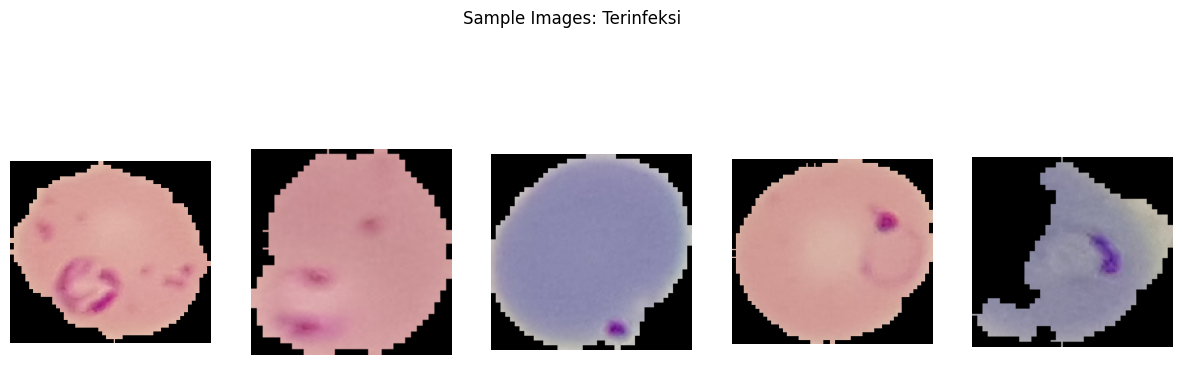

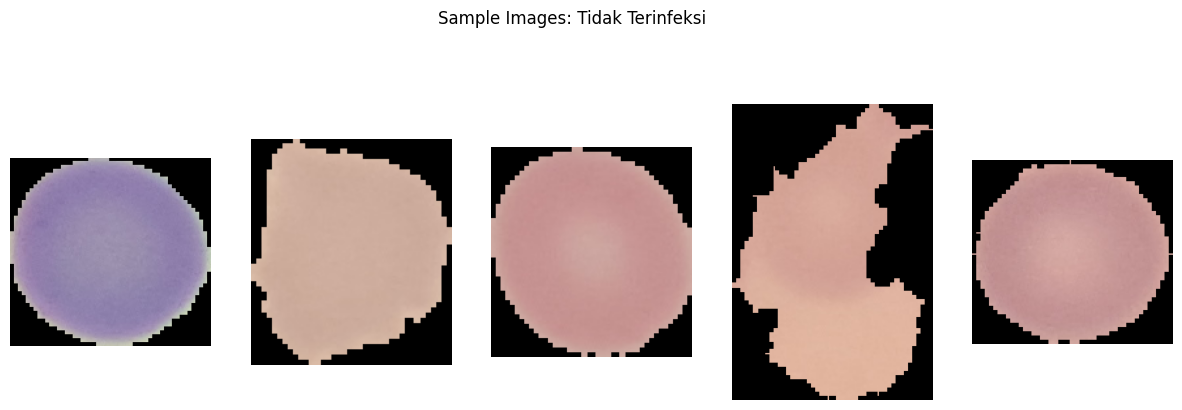

In [6]:
def show_images(label, count=5):
    subset = df[df['Labels'] == label].reset_index(drop=True)
    plt.figure(figsize=(15,5))
    for i in range(count):
        img = cv2.imread(subset['Image_Path'][i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, count, i+1)
        plt.imshow(img)
        plt.axis('off')
    plt.suptitle(f"Sample Images: {label}")
    plt.show()

show_images('Terinfeksi')
show_images('Tidak Terinfeksi')


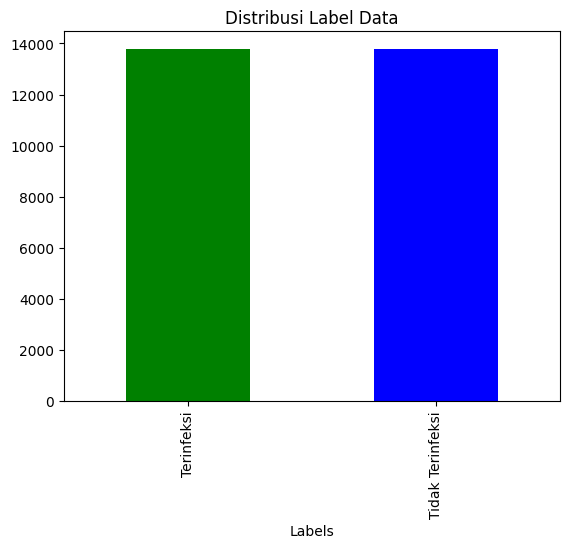

In [7]:
df['Labels'].value_counts().plot(kind='bar', color=['green', 'blue'])
plt.title('Distribusi Label Data')
plt.show()

## Data Splitting

In [8]:
warnings.filterwarnings('ignore')

train, test = train_test_split(df, test_size=0.2, random_state=42)

datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

In [9]:
from sklearn.model_selection import train_test_split

# Langkah 1: Bagi menjadi train+val dan test set terlebih dahulu
df_train_val, df_test = train_test_split(df, test_size=0.2, stratify=df['Labels'], random_state=42)

# Langkah 2: Bagi df_train_val menjadi train dan validation set
df_train, df_val = train_test_split(df_train_val, test_size=0.2, stratify=df_train_val['Labels'], random_state=42)

# Kemudian, buat generator untuk masing-masing set
x_train = datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='Image_Path',
    y_col='Labels',
    target_size=(224, 224),
    class_mode='binary',
    batch_size=32,
    shuffle=True,
    seed=42
)

x_val = datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='Image_Path',
    y_col='Labels',
    target_size=(224, 224),
    class_mode='binary',
    batch_size=32,
    shuffle=True,
    seed=42
)

x_test = datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='Image_Path',
    y_col='Labels',
    target_size=(224, 224),
    class_mode='binary',
    batch_size=32,
    shuffle=False  # untuk evaluasi, biasanya tidak di-shuffle
)


Found 17638 validated image filenames belonging to 2 classes.
Found 4409 validated image filenames belonging to 2 classes.
Found 5511 validated image filenames belonging to 2 classes.


## Modelling

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

def my_model(x_train, x_val, x_test, my_callbacks):
    # Definisi model
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
        tf.keras.layers.MaxPool2D(pool_size=(2,2)),

        tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        tf.keras.layers.MaxPool2D(pool_size=(2,2)),

        tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        tf.keras.layers.MaxPool2D(pool_size=(2,2)),

        tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        tf.keras.layers.MaxPool2D(pool_size=(2,2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(1024, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    # Kompilasi model
    model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    # Melatih model
    model_history = model.fit(
        x_train,
        validation_data=x_val,
        epochs=4,
        callbacks=my_callbacks
    )

    # Evaluasi model pada data testing
    test_loss, test_acc = model.evaluate(x_test)
    print(f"Testing Loss: {test_loss}")
    print(f"Testing Accuracy: {test_acc}")

    # Prediksi pada data testing dan tampilkan classification report
    y_pred = model.predict(x_test)
    y_pred = (y_pred > 0.5).astype("int32")  # Menyaring prediksi menjadi 0 atau 1

    # Ambil label sebenarnya dari x_test
    y_true = x_test.classes  # Dapatkan label asli dari generator

    # Menampilkan classification report
    print(classification_report(y_true, y_pred))

    return model_history, model

# Callback untuk early stopping
my_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
]

# Panggil fungsi dengan data training, validasi, dan testing
history_model, models = my_model(x_train, x_val, x_test, my_callbacks)


Epoch 1/4
552/552 ━━━━━━━━━━━━━━━━━━━━ 251s 449ms/step - accuracy: 0.5648 - loss: 7.8334 - val_accuracy: 0.7932 - val_loss: 0.4716
Epoch 2/4
552/552 ━━━━━━━━━━━━━━━━━━━━ 244s 442ms/step - accuracy: 0.8706 - loss: 0.3461 - val_accuracy: 0.9290 - val_loss: 0.2127
Epoch 3/4
552/552 ━━━━━━━━━━━━━━━━━━━━ 243s 441ms/step - accuracy: 0.9309 - loss: 0.2241 - val_accuracy: 0.9335 - val_loss: 0.2206
Epoch 4/4
552/552 ━━━━━━━━━━━━━━━━━━━━ 245s 444ms/step - accuracy: 0.9381 - loss: 0.1955 - val_accuracy: 0.9383 - val_loss: 0.2214
173/173 ━━━━━━━━━━━━━━━━━━━━ 59s 343ms/step - accuracy: 0.9206 - loss: 0.2236
Testing Loss: 0.2274119257926941
Testing Accuracy: 0.9188895225524902
173/173 ━━━━━━━━━━━━━━━━━━━━ 60s 342ms/step
              precision    recall  f1-score   support

           0       0.98      0.86      0.92      2756
           1       0.88      0.98      0.93      2755

    accuracy                           0.92      5511
   macro avg       0.93      0.92      0.92      5511
weighted avg

## Evaluasi dan Visualisasi

173/173 ━━━━━━━━━━━━━━━━━━━━ 60s 344ms/step - accuracy: 0.9194 - loss: 0.2212
Testing Loss: 0.2228272706270218
Testing Accuracy: 0.9199782013893127


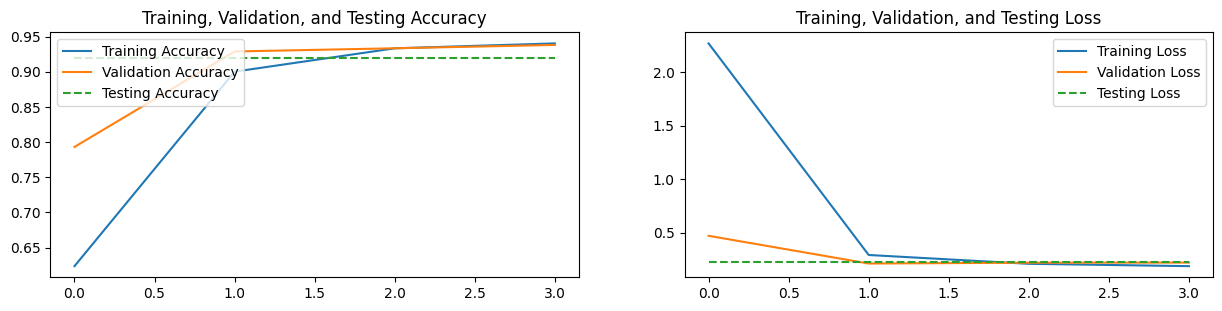

In [13]:
import matplotlib.pyplot as plt

# Evaluasi model pada data testing
test_loss, test_acc = models.evaluate(x_test)
print(f"Testing Loss: {test_loss}")
print(f"Testing Accuracy: {test_acc}")

# Mendapatkan data history dari training dan validation
accuracy = history_model.history['accuracy']
loss = history_model.history['loss']
validation_loss = history_model.history['val_loss']
validation_accuracy = history_model.history['val_accuracy']

# Menambahkan testing accuracy dan testing loss
# Untuk testing, kita hanya punya satu nilai loss dan akurasi, jadi kita duplikasi nilai tersebut sepanjang training epochs
test_accuracy = [test_acc] * len(accuracy)
test_loss_values = [test_loss] * len(accuracy)

# Plot hasilnya
plt.figure(figsize=(15, 7))

# Plot Training dan Validation Accuracy
plt.subplot(2, 2, 1)
plt.plot(range(len(accuracy)), accuracy, label='Training Accuracy')
plt.plot(range(len(accuracy)), validation_accuracy, label='Validation Accuracy')
plt.plot(range(len(accuracy)), test_accuracy, label='Testing Accuracy', linestyle='--')
plt.legend(loc='upper left')
plt.title('Training, Validation, and Testing Accuracy')

# Plot Training dan Validation Loss
plt.subplot(2, 2, 2)
plt.plot(range(len(accuracy)), loss, label='Training Loss')
plt.plot(range(len(accuracy)), validation_loss, label='Validation Loss')
plt.plot(range(len(accuracy)), test_loss_values, label='Testing Loss', linestyle='--')
plt.legend(loc='upper right')
plt.title('Training, Validation, and Testing Loss')

plt.show()


## Konversi Model

In [14]:
# Simpan model ke format SavedModel
models.export('my_model_savedmodel')

Saved artifact at 'my_model_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_13')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138868896304208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138868895315344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138868895317648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138868895316304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138868895316880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138868895314384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138868895316496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138868895315152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138868895314576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138868895313424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13886889

In [15]:
import shutil

# Membuat ZIP dari folder 'my_model_savedmodel'
shutil.make_archive('my_model_savedmodel', 'zip', 'my_model_savedmodel')

'/content/my_model_savedmodel.zip'

In [16]:
import tensorflow as tf

# Mengonversi model SavedModel ke format TFLite
converter = tf.lite.TFLiteConverter.from_saved_model('my_model_savedmodel')

# Anda dapat mengoptimalkan model dengan beberapa pilihan (optional)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Gunakan optimasi default
# converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]  # Untuk optimasi lebih lanjut (opsional)

# Lakukan konversi ke TFLite
tflite_model = converter.convert()

# Menyimpan model ke file .tflite
with open('my_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("Model berhasil disimpan sebagai my_model.tflite")

Model berhasil disimpan sebagai my_model.tflite


In [18]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [19]:
import tensorflowjs as tfjs

# Konversi model SavedModel ke format TF.js
tfjs.converters.save_keras_model(models, 'my_model_tfjs')

failed to lookup keras version from the file,
    this is likely a weight only file


In [20]:
import shutil

# Membuat file ZIP dari folder TF.js model
shutil.make_archive('my_model_tfjs', 'zip', 'my_model_tfjs')


'/content/my_model_tfjs.zip'

In [21]:
!pip install pipreqsnb

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.3 MB/s eta 0:00:00
  Created wheel for pipreqsnb: filename=pipreqsnb-0.2.4-py3-none-any.whl size=4128 sha256=bc3d7a2f98ddca31029a4077322360cf5858874e5119aaaa1d477d8348ea8875
  Stored in directory: /root/.cache/pip/wheels/48/2a/a3/6caa16bfb260624b06acb2a0eeb0bc45c2cd2f0ee2b5ac2d84
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=34ee65dbaf2634917f152ef1fcb806f5ca31b481e00cd1d9e95d8ea8ae9cc9ad
  Stored in directory: /root/.cache/pip/wheels/1a/b0/8c/4b75c4116c31f83c8f9f047231251e13cc74481cca4a78a9ce
Successfully built pipreqsnb docopt
  Attempting uninstall: ipython
    Found existing installation: ipython 7.34.0
    Uninstalling ipython-7.34.0:
      Successfully uninstalled ipython-7.34.0
ERROR: pip's dependency resolver does not 

In [ ]:
!pip freeze > requirements.txt


In [ ]:
from google.colab import files
files.download('requirements.txt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>